<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/1_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Decision Trees
### Agenda
1. Introduction to Decision Trees
2. The Decision Tree Algorithms
3. Decision Tree for Classification
4. Decision Tree for Regression
5. Advantages & Limitations of Decision Trees

### 1. Introduction to Decision Trees
```
* Non-parametric supervised learning method for regression & classification
* It's similar to playing 'dumb charades'.
* A good algorithm will have less & right questions compared to not-so-good one
* The nodes are questions & leafs are prediction
```


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [57]:
play_data = pd.read_csv('https://raw.githubusercontent.com/edyoda/data-science-complete-tutorial/refs/heads/master/Data/tennis.csv.txt')

In [58]:
play_data

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


* A decision tree for above data

<img src="https://github.com/awantik/machine-learning-slides/blob/master/dt4.PNG?raw=true" width="600px">

### 2. Decision Tree Algorithm

* Decision Tree is based on (CART) which is advancement of ID3, developed in 1986 by Ross Quinlan.
* ID3 works when feature data & target data both are categorical in nature
* C4.5 is an advancement of ID3, it coverts continues features into categorical features. Then, proceeds with ID3
* CART is based on C4.5, with slight advancement of 'target can be continues'.
* scikit-learn decision trees are based on CART

#### Criterion of creating Decision Tree
* Entropy - Objective of CART is to maximize information gain in each split
* Gini Impurity - If classes are mixed, gini impurity is maximul
##### Both the approaches, yields almost same results. We will discuss algorithm using Entropy


### Entropy of play
* Entropy(play) = – p(Yes) . log2p(Yes) – p(No) . log2p(No)

In [59]:
play_data.play.value_counts()

,count
play,
yes,9
no,5


In [60]:
Entropy_Play = -(9/14)*np.log2(9/14) -(5/14)*np.log2(5/14)

In [61]:
Entropy_Play

np.float64(0.9402859586706311)

### Information Gain
* The information gain is based on the decrease in entropy after a dataset is split on an attribute.
* Constructing a decision tree is all about finding attribute that returns the highest information gain (i.e., the most homogeneous branches).
* Gain(S, A) = Entropy(S) – ∑ [ p(S|A) . Entropy(S|A) ]
* We intend to choose the attribute, splitting by which information gain will be the most
* Next step is calculating information gain for all attributes

#### Information Gain on splitting by Outlook
* Gain(Play, Outlook) = Entropy(Play) – ∑ [ p(Play|Outlook) . Entropy(Play|Outlook) ]
* Gain(Play, Outlook) = Entropy(Play) – [ p(Play|Outlook=Sunny) . Entropy(Play|Outlook=Sunny) ] – [ p(Play|Outlook=Overcast) . Entropy(Play|Outlook=Overcast) ]  – [ p(Play|Outlook=Rain) . Entropy(Play|Outlook=Rain) ]

In [62]:
play_data[play_data.outlook == 'sunny']

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
10,sunny,mild,normal,True,yes


In [63]:
# Entropy(Play|Outlook=Sunny)
Entropy_Play_Outlook_Sunny =-(3/5)*np.log2(3/5) -(2/5)*np.log2(2/5)

In [64]:
Entropy_Play_Outlook_Sunny

np.float64(0.9709505944546686)

In [65]:
play_data[play_data.outlook == 'overcast']

,outlook,temp,humidity,windy,play
2,overcast,hot,high,False,yes
6,overcast,cool,normal,True,yes
11,overcast,mild,high,True,yes
12,overcast,hot,normal,False,yes


In [66]:
# Entropy(Play|Outlook=overcast)
# Since, it's a homogenous data entropy will be 0

In [67]:
play_data[play_data.outlook == 'rainy']

,outlook,temp,humidity,windy,play
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
9,rainy,mild,normal,False,yes
13,rainy,mild,high,True,no


In [68]:
# Entropy(Play|Outlook=rainy)
Entropy_Play_Outlook_Rain = -(2/5)*np.log2(2/5) - (3/5)*np.log2(3/5)

In [69]:
Entropy_Play_Outlook_Rain

np.float64(0.9709505944546686)

#### Gain on splitting by attribute outlook

In [70]:
#Gain(Play, Outlook) = Entropy(Play) – [ p(Play|Outlook=Sunny) . Entropy(Play|Outlook=Sunny) ] –
#[ p(Play|Outlook=Overcast) . Entropy(Play|Outlook=Overcast) ] – [ p(Play|Outlook=Rain) . Entropy(Play|Outlook=Rain) ]

Entropy_Play - (5/14)*Entropy_Play_Outlook_Sunny - (4/14)*0 - (5/14) * Entropy_Play_Outlook_Rain

np.float64(0.24674981977443933)

#### Other gains
* Gain(Play, Temperature) - 0.029
* Gain(Play, Humidity) - 0.151
* Gain(Play, Wind) - 0.048

#### Conclusion - Outlook is winner & thus becomes root of the tree
<img src="https://i1.wp.com/sefiks.com/wp-content/uploads/2017/11/tree-v1.png?zoom=1.25&resize=728%2C252&ssl=1" width="600px">

### Time to find the next splitting criteria

In [71]:
play_data[play_data.outlook == 'overcast']

,outlook,temp,humidity,windy,play
2,overcast,hot,high,False,yes
6,overcast,cool,normal,True,yes
11,overcast,mild,high,True,yes
12,overcast,hot,normal,False,yes


##### Conclusion - If outlook is overcast, play is true

### Let's find the next splitting feature

In [72]:
play_data[play_data.outlook == 'sunny']

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
10,sunny,mild,normal,True,yes


In [73]:
# Entropy(Play_Sunny|)
Entropy_Play_Outlook_Sunny =-(3/5)*np.log2(3/5) -(2/5)*np.log2(2/5)

In [74]:
Entropy_Play_Outlook_Sunny

np.float64(0.9709505944546686)

### Information Gain for humidity

In [75]:
#Entropy for attribute high = 0, also entropy for attribute normal = 0
Entropy_Play_Outlook_Sunny - (3/5)*0 - (2/5)*0

np.float64(0.9709505944546686)

### Information Gain for windy
* False -> 3 -> [1+ 2-]
* True -> 2 -> [1+ 1-]

In [76]:
Entropy_Wind_False = -(1/3)*np.log2(1/3) - (2/3)*np.log2(2/3)

In [77]:
Entropy_Wind_False

np.float64(0.9182958340544896)

In [78]:
Entropy_Play_Outlook_Sunny - (3/5)* Entropy_Wind_False  - (2/5)*1

np.float64(0.01997309402197489)

### Information Gain for temperature
* hot -> 2 -> [2- 0+]
* mild -> 2 -> [1+ 1-]
* cool -> 1  -> [1+ 0-]

In [79]:
Entropy_Play_Outlook_Sunny - (2/5)*0 - (1/5)*0 - (2/5)* 1

np.float64(0.5709505944546686)

#### Conclusion : Humidity is the best choice on sunny branch

<img src="https://github.com/awantik/machine-learning-slides/blob/master/dt3.PNG?raw=true" width="600px">

In [80]:
play_data[(play_data.outlook == 'sunny') & (play_data.humidity == 'high')]

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
7,sunny,mild,high,False,no


In [81]:
play_data[(play_data.outlook == 'sunny') & (play_data.humidity == 'normal')]

,outlook,temp,humidity,windy,play
8,sunny,cool,normal,False,yes
10,sunny,mild,normal,True,yes


### Splitting the rainy branch

In [82]:
play_data[play_data.outlook == 'rainy']

,outlook,temp,humidity,windy,play
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
9,rainy,mild,normal,False,yes
13,rainy,mild,high,True,no


In [83]:
# Entropy(Play_Rainy|)
Entropy_Play_Outlook_Rainy =-(3/5)*np.log2(3/5) -(2/5)*np.log2(2/5)

In [84]:
Entropy_Play_Outlook_Rainy

np.float64(0.9709505944546686)

### Information Gain for temp
* mild -> 3 [2+ 1-]
* cool -> 2 [1+ 1-]

In [85]:
Entropy_Play_Outlook_Rainy - (3/5)*0.918 - (2/5)*1

np.float64(0.020150594454668602)

### Information Gain for Windy

In [86]:
Entropy_Play_Outlook_Rainy - (2/5)*0 - (3/5)*0

np.float64(0.9709505944546686)

### Information Gain for Humidity
* High -> 2 -> [1+ 1-]
* Normal -> 3 -> [2+ 1-]

In [87]:
Entropy_Play_Outlook_Rainy_Normal = -(1/3)*np.log2(1/3) - (2/3)*np.log2(2/3)

In [88]:
Entropy_Play_Outlook_Rainy_Normal

np.float64(0.9182958340544896)

In [89]:
Entropy_Play_Outlook_Rainy - (2/5)*1 - (3/5)*Entropy_Play_Outlook_Rainy_Normal

np.float64(0.01997309402197489)

### Final Tree

<img src="https://github.com/awantik/machine-learning-slides/blob/master/dt4.PNG?raw=true" width="600px">

### 3. Decision Tree for Classification
* The leaf nodes of decision tree decides the class
* CART will convert features with continues values into categorical values
* Different tree will be generated with same data given in different order

In [90]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz, ExtraTreeClassifier

In [91]:
iris = load_iris()

In [92]:
iris.data[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [93]:
iris.target[:5]

array([0, 0, 0, 0, 0])

In [94]:
dt = DecisionTreeClassifier(criterion='entropy')

In [95]:
from sklearn.model_selection import train_test_split

In [96]:
trainX,testX,trainY,testY = train_test_split(iris.data, iris.target)

In [97]:
dt.fit(trainX,trainY)

DecisionTreeClassifier(criterion='entropy')

In [98]:
export_graphviz(dt,'dt.tree')

### Visualizing the tree
* http://www.webgraphviz.com/

* Criteria - Entropy
<img src="https://github.com/awantik/machine-learning-slides/blob/master/dt6.PNG?raw=true">

In [99]:
dt.predict(testX)

array([2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 0, 2, 2, 1, 1, 2, 2, 2, 2, 0, 1, 1,
       1, 2, 2, 1, 1, 0, 0, 1, 0, 2, 2, 1, 0, 0, 0, 2])

#### Feature Importances
* Important features will be higher up the tree
* We can use this techniques to identify important features

In [100]:
dt.feature_importances_

array([0.        , 0.        , 0.36865816, 0.63134184])

#### Visualizing Decision Decision Boundry

In [101]:
from sklearn.datasets import make_blobs

In [102]:
X,Y = make_blobs(n_features=2, n_samples=1000, cluster_std=.8, centers=4, random_state=6)

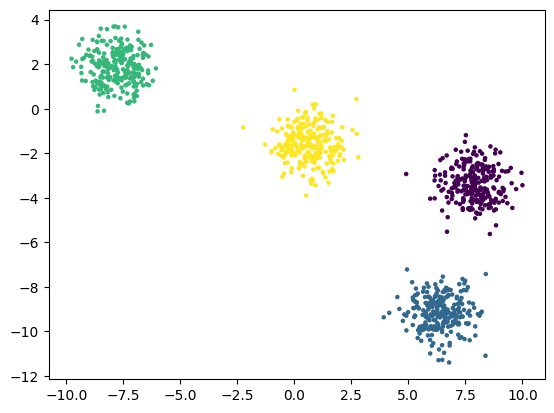

In [103]:
plt.scatter(X[:,0],X[:,1],c=Y,s=5, cmap='viridis')

In [104]:
dt = DecisionTreeClassifier()

In [105]:
dt.fit(X,Y)

DecisionTreeClassifier()

In [106]:
plot_step = 0.2
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

In [107]:
outcome = dt.predict(np.c_[xx.ravel(), yy.ravel()])

In [108]:
xx.shape

(86, 109)

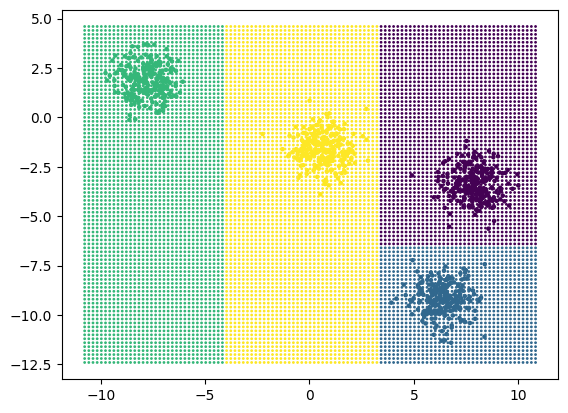

In [109]:
plt.scatter(X[:,0],X[:,1],c=Y,s=5,cmap='viridis')
plt.scatter(xx.ravel(),yy.ravel(),c=outcome,s=1,alpha=1, cmap='viridis')
plt.show()

### 4. Decision Tree for Regression
* Continues target is predicted with Tree.
* ID3 is modified for regression by replacing Information Gain with Mean Squared Error.
* Decision Tree tries to partition data into subsets of homogenous contents ( minimize mean squared error )

In [110]:
play_time = pd.read_csv('https://raw.githubusercontent.com/edyoda/data-science-complete-tutorial/refs/heads/master/Data/tennis-time.csv.txt')

In [111]:
play_time

,outlook,temp,humidity,windy,time
0,sunny,hot,high,False,26
1,sunny,hot,high,True,30
2,overcast,hot,high,False,48
3,rainy,mild,high,False,46
4,rainy,cool,normal,False,62
5,rainy,cool,normal,True,23
6,overcast,cool,normal,True,43
7,sunny,mild,high,False,36
8,sunny,cool,normal,False,38
9,rainy,mild,normal,False,48


In [112]:
from sklearn.preprocessing import LabelEncoder
for col in ['outlook','temp','humidity','windy']:
    le = LabelEncoder()
    play_time[col] = le.fit_transform(play_time[col])

In [113]:
from sklearn.tree import DecisionTreeRegressor

In [114]:
dt = DecisionTreeRegressor()

In [115]:
dt.fit(play_time.drop('time',axis=1), play_time.time)

DecisionTreeRegressor()

In [116]:
export_graphviz(dt,'regtree.dot',feature_names=['outlook','temp','humidity','windy'])

In [117]:
play_time

,outlook,temp,humidity,windy,time
0,2,1,0,0,26
1,2,1,0,1,30
2,0,1,0,0,48
3,1,2,0,0,46
4,1,0,1,0,62
5,1,0,1,1,23
6,0,0,1,1,43
7,2,2,0,0,36
8,2,0,1,0,38
9,1,2,1,0,48


<img src="https://github.com/awantik/machine-learning-slides/blob/master/dt8.PNG?raw=true">

In [118]:
dt.predict([[2,1,1,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([23.])

In [119]:
dt.feature_importances_

array([0.29746223, 0.38850867, 0.14515689, 0.16887221])

### 5. Advantages of Decision Tree
* Highly Interpretable & can be visualized
* Minimal data preprocessing - missing data handling, normalizing, one-hot-encoding not required
* Handle both neumerical & categorical values
* Supports multi-output

#### Understanding Multi-Output Problem
* Supervised learning problem with multiple outputs, target is 2D
* If there is no correlation between target, they can be independently calculated using N models ( in case of N targets )
* Since predictors are same, outputs are likely to be correlated.
* Like many other models, decision trees allows for multi-output targets

### 6. Limitations of Decision Tree
* Overfitting - height of tree kept growing with addition of more data
* Slight changes in data or order of data can change the tree
* Imbalanced classes datasets creates biased tree so data needs balancing

##### The above two limitations are handled by ensemble methods

#### Pruning
* A technique of machine learning which reduces height of the tree by chopping off parts of the tree that's not doing anything significant in prediction
* Two types of pruning - Prepruning & Postpruning
  - Prepruning : Don't allow tree to grow beyond this point
  - Postpruning : Allows tree to grow as much as possible, then prune the tree

* Pruning is not currently supported in scikit
* This can be achieved using min_samples_leaf & max_height

![](img/questions-01.png)

# 1. Conceptual Questions

1. Calculate the self entropy of the following coin with bias :  
  a. p=0.5  
  b. p=0.9  
  c. p=1  
  
2. Calculate the cross entropy of the dice with bias=\[ 0.1, 0.2, 0.1, 0.15, 0.15, 0.3 \] in the following cases  :  
  a. output=1  
  b. output=2  
  c. output=6  
  
3. Tell the cases where you think that cross entropy would be higher for a coin.  
  a. p(H)=0.9, outcome=Head  
  b. p(H)=0.1, outcome=Tail  
  c. p(H)=0.99, outcome=Tail  
  
4. What is Information Gain in terms of Entropy? In case of predicting the number of wickets, what would be information gain on knowledge of weather?
  
5. What is Gini's Impurity? Why do we use it more often in popular Decision Tree algorithms like CART, rather then entropy? What does the formula signify?
  
6. If the size of feature vector for data point is 5, what will be the depth of the tree?  
  
7. What is the disadvantage of having a tree branched over all the features ? How do we control/prun the growth of tree?  

8. Why is there an aversion in the ML community for using decision tree as a primary choice for building a classifier?

9. Think about the advantages/Disadvantages of Decision Tree vs Linear Regression.

# 2. Programming Questions
1. Build a decision Tree Classifier from scratch in Python, Choose the features based on Information Gain
2. Plot self entropy and Gini's Impurity against the bias in case of coin tossing experiment
3. Try to use Decision Tree Classifier to find out if the person will get high, medium or low salary based on the rest of the features. The data is given bellow. Visualize the same using graphViz

In [122]:
adult_data = pd.read_csv('https://raw.githubusercontent.com/zekelabs/data-science-complete-tutorial/master/Data/adult.data.txt')

In [123]:
adult_data.head()

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
